# Feature Engineering – Construção da Carteira de Crédito

Objetivos:
- Transformar colunas textuais em formatos numéricos (term, int_rate, grade)
- Construir PD por segmento com *Bayesian smoothing*
- Modelar LGD usando distribuição Beta com média por grade
- Gerar EAD (já presente) e construir a tabela final para simulação Monte Carlo
- Gerar checks e salvar arquivo pronto para simulação

### Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta

sns.set_theme(style="whitegrid")
np.random.seed(42)

### Carregar dataset processado

In [2]:
df = pd.read_parquet("../data/processed/credit_risk_clean.parquet")

In [3]:
df.shape

(597989, 9)

In [4]:
df.head()

,loan_amnt,term,int_rate,grade,fico_range_low,fico_range_high,default,fico_score,EAD
0,3600.0,36 months,13.99,C,675.0,679.0,0,677.0,3600.0
1,24700.0,36 months,11.99,C,715.0,719.0,0,717.0,24700.0
2,20000.0,60 months,10.78,B,695.0,699.0,0,697.0,20000.0
3,10400.0,60 months,22.45,F,695.0,699.0,0,697.0,10400.0
4,11950.0,36 months,13.44,C,690.0,694.0,0,692.0,11950.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597989 entries, 0 to 597988
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   loan_amnt        597989 non-null  float64
 1   term             597989 non-null  object 
 2   int_rate         597989 non-null  float64
 3   grade            597989 non-null  object 
 4   fico_range_low   597989 non-null  float64
 5   fico_range_high  597989 non-null  float64
 6   default          597989 non-null  int8   
 7   fico_score       597989 non-null  float64
 8   EAD              597989 non-null  float64
dtypes: float64(6), int8(1), object(2)
memory usage: 37.1+ MB


### Tratamento da variável TERM

In [6]:
# TERM -> inteiro (remover " months" e converter)
df['term'] = (
    df['term']
    .str.replace(' months','')
    .astype(int)
)

### Transformação de GRADE

In [7]:
grade_map = {
'A':1,
'B':2,
'C':3,
'D':4,
'E':5,
'F':6,
'G':7
}

df['grade_num'] = df['grade'].map(grade_map)

### Estrutura da carteira

In [8]:
print("Número de contratos:", len(df))
print("Exposição total:", df['EAD'].sum())
print("Ticket médio:", df['EAD'].mean())

Número de contratos: 597989
Exposição total: 8897981225.0
Ticket médio: 14879.840975335666


### Segmentação de Score de Crédito

In [9]:
df['score_segment'] = pd.cut(
    df['fico_score'],
    bins=[620,660,700,740,850],
    labels=[
        'Low',
        'Regular',
        'Good',
        'Excellent'
    ],
    include_lowest=True
)

df['score_segment'].value_counts()

score_segment
Regular      337063
Good         176424
Excellent     84500
Low               2
Name: count, dtype: int64

### Correlação das features

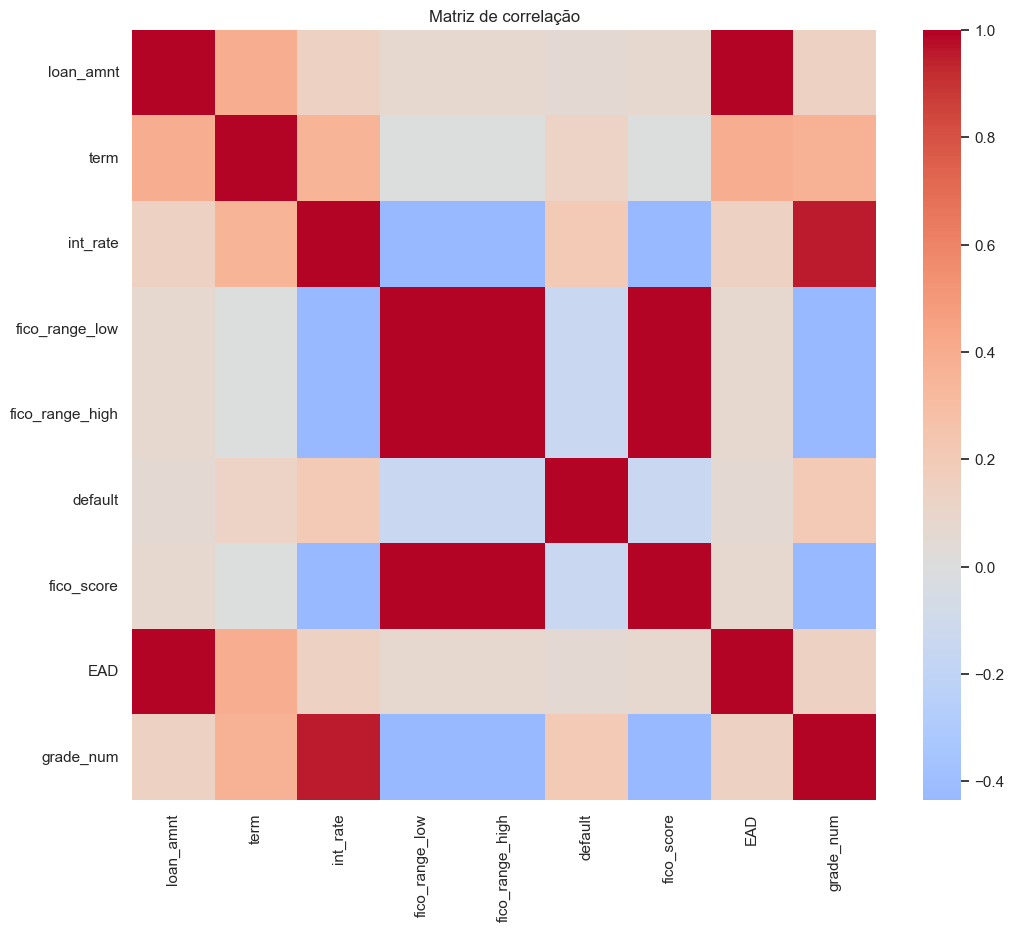

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Matriz de correlação")

plt.show()


### Estimativa de PD por segmento de score

In [11]:
# Taxa global de default
global_pd = df['default'].mean()

# Agrupar por segmento
pd_segment = (
    df.groupby('score_segment')
    .agg(
        defaults=('default','sum'),
        volume=('default','count')
    )
)

# Bayesian smoothing parameter
k = 50

pd_segment['pd_smoothed'] = (
    (pd_segment['defaults'] + k * global_pd) /
    (pd_segment['volume'] + k)
)

pd_segment

C:\Users\letic\AppData\Local\Temp\ipykernel_26824\1648291765.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('score_segment')


,defaults,volume,pd_smoothed
score_segment,,,
Low,0,2,0.266427
Regular,109383,337063,0.324511
Good,43514,176424,0.246653
Excellent,12796,84500,0.151506


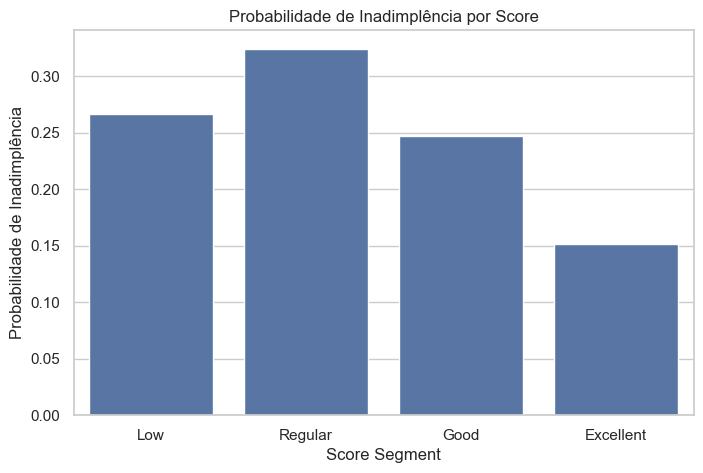

In [12]:
# Gráfico de monotonicidade da PD por score

plt.figure(figsize=(8,5))

sns.barplot(
    x=pd_segment.index,
    y=pd_segment['pd_smoothed']
)

plt.title("Probabilidade de Inadimplência por Score")
plt.xlabel("Score Segment")
plt.ylabel("Probabilidade de Inadimplência")

plt.show()

In [13]:
# Exposição por segmento de score

exposure_segment = (
    df.groupby('score_segment')
    .agg(
        exposure=('EAD','sum'),
        contracts=('EAD','count')
    )
)

exposure_segment['share_exposure'] = (
    exposure_segment['exposure'] /
    exposure_segment['exposure'].sum()
)

exposure_segment

C:\Users\letic\AppData\Local\Temp\ipykernel_26824\422655078.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('score_segment')


,exposure,contracts,share_exposure
score_segment,,,
Low,4.200000e+03,2,4.720172e-07
Regular,4.814484e+09,337063,5.410760e-01
Good,2.770550e+09,176424,3.113684e-01
Excellent,1.312943e+09,84500,1.475552e-01


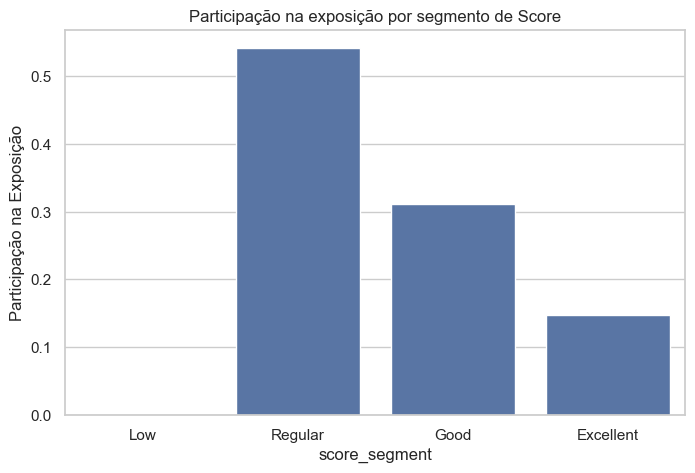

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=exposure_segment.index,
    y=exposure_segment['share_exposure']
)

plt.title("Participação na exposição por segmento de Score")
plt.ylabel("Participação na Exposição")

plt.show()

### Visualizar PD por segmento

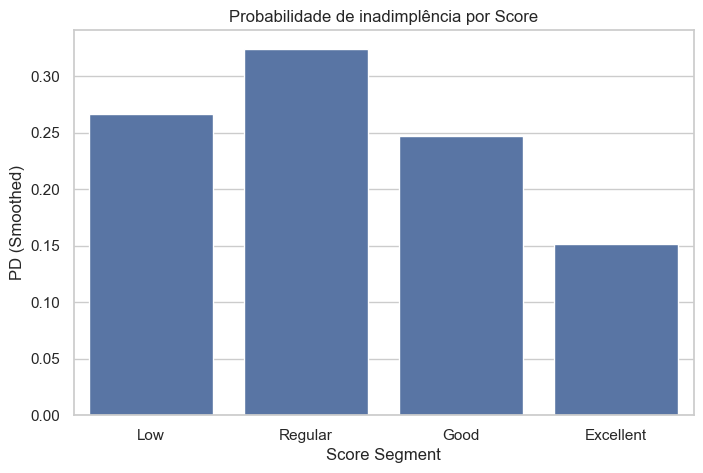

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=pd_segment.index,
    y=pd_segment['pd_smoothed']
)

plt.title("Probabilidade de inadimplência por Score")
plt.ylabel("PD (Smoothed)")
plt.xlabel("Score Segment")

plt.show()

### Atribuir PD para cada cliente

In [16]:
pd_map = pd_segment['pd_smoothed'].to_dict()

df['PD'] = df['score_segment'].map(pd_map)

df[['fico_score','score_segment','PD']].head()

,fico_score,score_segment,PD
0,677.0,Regular,0.324511
1,717.0,Good,0.246653
2,697.0,Regular,0.324511
3,697.0,Regular,0.324511
4,692.0,Regular,0.324511


### Modelagem da LGD

In [17]:
# LGD média assumida para crédito não garantido

lgd_mean = 0.45
lgd_std = 0.15

# Converter média e desvio em parâmetros da beta

alpha = ((1 - lgd_mean) / lgd_std**2 - 1 / lgd_mean) * lgd_mean**2
beta_param = alpha * (1 / lgd_mean - 1)

df['LGD'] = beta.rvs(
    alpha,
    beta_param,
    size=len(df)
)

### Visualizar distribuição da LGD

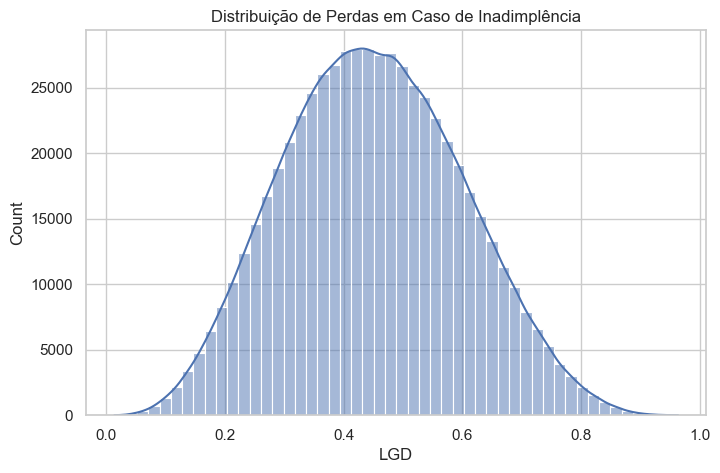

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['LGD'], bins=50, kde=True)

plt.title("Distribuição de Perdas em Caso de Inadimplência")
plt.xlabel("LGD")

plt.show()                                                                                                                                                                                                                                                                                                                                                                                  

### Construir carteira final

In [19]:
portfolio = df[['EAD','PD','LGD']].copy()

portfolio['PD'] = portfolio['PD'].astype(float)
portfolio['LGD'] = portfolio['LGD'].astype(float)
portfolio['EAD'] = portfolio['EAD'].astype(float)

portfolio.head()

,EAD,PD,LGD
0,3600.0,0.324511,0.520068
1,24700.0,0.246653,0.443429
2,20000.0,0.324511,0.538235
3,10400.0,0.324511,0.335353
4,11950.0,0.324511,0.708696


### Estatísticas da carteira

In [20]:
portfolio.describe()

,EAD,PD,LGD
count,597989.000000,597989.000000,597989.000000
mean,14879.840975,0.277094,0.450245
std,8956.382916,0.061396,0.150085
min,500.000000,0.151506,0.013656
25%,7700.000000,0.246653,0.341200
50%,13475.000000,0.324511,0.446602
75%,20700.000000,0.324511,0.555841
max,40000.000000,0.324511,0.963741


### Perda esperada da carteira

In [21]:
portfolio['expected_loss'] = (
    portfolio['PD'] *
    portfolio['LGD'] *
    portfolio['EAD']
)

portfolio['expected_loss'].sum()

np.float64(1100174172.8295665)

### Visualizar distribuição da perda esperada

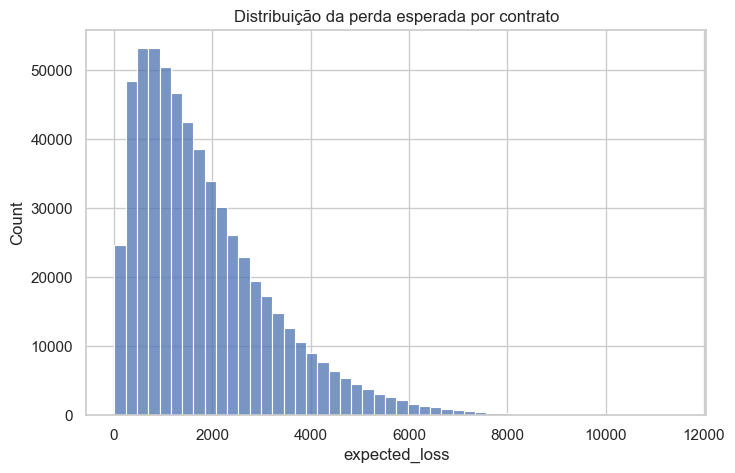

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    portfolio['expected_loss'],
    bins=50
)

plt.title("Distribuição da perda esperada por contrato")

plt.show()

In [23]:
print("PD média da carteira:", portfolio['PD'].mean())
print("LGD média:", portfolio['LGD'].mean())
print("Exposição total:", portfolio['EAD'].sum())

PD média da carteira: 0.277093662080568
LGD média: 0.45024531128228057
Exposição total: 8897981225.0


### Salvar carteira para simulação

In [24]:
portfolio.to_parquet(
    "../data/processed/credit_portfolio_simulation.parquet",
    index=False
)

## Conclusão

Neste notebook foi realizada a etapa de **feature engineering da carteira de crédito**, com o objetivo de transformar os dados explorados anteriormente em uma estrutura adequada para modelagem de risco.

Inicialmente, as variáveis foram tratadas e padronizadas, permitindo a construção de métricas fundamentais para análise de crédito. A partir do score de crédito, os clientes foram segmentados em diferentes perfis de risco, possibilitando a estimativa da **Probabilidade de Default (PD)** por faixa de score. Para tornar essa estimativa mais robusta, foi aplicado um processo de **suavização Bayesiana**, reduzindo possíveis distorções causadas por segmentos com menor volume de observações.

Além disso, foi modelada a **Loss Given Default (LGD)** utilizando uma distribuição probabilística, permitindo representar a variabilidade da severidade de perda em caso de inadimplência. Com isso, foi possível estruturar a carteira final contendo os três componentes essenciais da modelagem de risco de crédito: **Exposure at Default (EAD), Probability of Default (PD) e Loss Given Default (LGD)**.

A carteira resultante apresentou:

* **PD média:** 27,7%
* **LGD média:** 45,0%
* **Exposição total:** aproximadamente **8,9 bilhões**
* **Perda esperada:** aproximadamente **1,1 bilhão**

Esses resultados indicam que, considerando as probabilidades de inadimplência e a severidade média das perdas, a carteira apresenta um nível relevante de risco esperado. A estrutura construída neste notebook permite quantificar esse risco de forma consistente e servirá como base para a próxima etapa do projeto, onde será aplicada uma **simulação de Monte Carlo** para estimar a distribuição de perdas da carteira e calcular métricas avançadas de risco, como **Value at Risk (VaR)** e **Expected Shortfall**.

Assim, este notebook cumpre seu objetivo ao preparar a carteira para análises quantitativas mais avançadas de gestão de risco de crédito.
